# Tensor Logic from Scratch: When a Logical Rule *Is* a Matrix Multiplication

*Companion notebook — W32 trend tutorial, [Reasoning on Purpose: Neuro-Symbolic AI and the Confidence to Act](https://artifocial.com/blog/neuro-symbolic-reasoning-2026-aug-6), and basics, [Neuro-Symbolic AI Explained](https://artifocial.com/blog/neuro-symbolic-ai-explained-2026-aug-8).*

The single startling idea behind Pedro Domingos's [Tensor Logic](https://arxiv.org/abs/2510.12269) (Oct 2025) is that **a logical inference rule, under the right encoding, is carried out by the very same operation a neural network runs millions of times a second: an index-summing contraction (a matrix multiply).**

We prove it on a tiny family tree, and — because the board asked us to show where *practice is trickier than theory* — we do not stop at "it works." We show the one place the slogan is loose: a real-number `einsum` counts **derivation paths**, not truth values, so recovering logic takes either a clip or a switch to the **Boolean semiring** ($\vee$ for $+$, $\wedge$ for $\times$) that the [trend tutorial](https://artifocial.com/blog/neuro-symbolic-reasoning-2026-aug-6) names explicitly. Then we get the recursive `ancestor` rule by contracting to a fixpoint — the miniature of the [implementation paper's](https://arxiv.org/abs/2601.17188) genealogy result. CPU-only, milliseconds, every matrix inspectable.

In [1]:
# [Code 01] Environment setup — uv-first, pip fallback (works everywhere)
import importlib, subprocess, sys, shutil

def ensure(pkgs):
    missing = [p for p in pkgs if importlib.util.find_spec(p) is None]
    if not missing:
        return
    if shutil.which("uv"):
        subprocess.check_call(["uv", "pip", "install", "--quiet", "--system", *missing])
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])

ensure(["numpy", "matplotlib"])

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
print("NumPy", np.__version__)

NumPy 2.5.1


## Facts as a Boolean Tensor

A knowledge base of `parent(a, b)` facts is a boolean adjacency matrix. We let `P[i, j] = 1` mean **"person `i` is a parent of person `j`."** Seven people, a handful of edges — small enough to read by eye. Note the two facts that will matter later: **Ada is a parent of both Cy and Dee**, and **both Cy and Dee are parents of Eve** — so Ada reaches Eve two different ways.

In [2]:
# [Code 02] The family as a boolean "parent-of" tensor:  P[i,j] = 1  iff  i is a parent of j
names = ["Ada", "Ben", "Cy", "Dee", "Eve", "Finn", "Gwen"]
N = len(names)
idx = {n: i for i, n in enumerate(names)}

P = np.zeros((N, N), dtype=np.int64)
edges = [("Ada","Cy"), ("Ben","Cy"), ("Cy","Eve"), ("Dee","Eve"),
         ("Eve","Gwen"), ("Ada","Dee"), ("Finn","Dee")]
for a, b in edges:
    P[idx[a], idx[b]] = 1

print("parent-of matrix P:\n", P)

parent-of matrix P:
 [[0 0 1 1 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1]
 [0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0]]


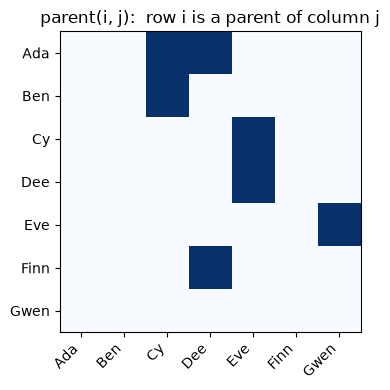

In [3]:
# [Result 01] The facts as a heatmap — this boolean grid IS our knowledge base
plt.figure(figsize=(4.4, 4))
plt.imshow(P, cmap="Blues", vmin=0, vmax=1)
plt.xticks(range(N), names, rotation=45, ha="right"); plt.yticks(range(N), names)
plt.title("parent(i, j):  row i is a parent of column j")
plt.tight_layout(); plt.show()

## The Rule as One Contraction

The grandparent rule in Datalog is:

```
grandparent(i, k) :- parent(i, j), parent(j, k).
```

"There exists a middle person `j` such that both facts hold" is exactly **OR over `j` of (AND of the two facts)** — the boolean form of an index-summing contraction $\bigvee_j P_{ij}\wedge P_{jk}$. That shared, summed-away index `j` is the whole rule.

In [4]:
# [Code 03] The RULE as a single tensor contraction over the shared index j
# grandparent(i,k) = OR_j ( parent(i,j) AND parent(j,k) )
GP_tensor = (np.einsum("ij,jk->ik", P, P) > 0).astype(np.int64)
gp_pairs = [(names[i], names[k]) for i in range(N) for k in range(N) if GP_tensor[i, k]]
print("grandparent tensor:\n", GP_tensor)
print("derived grandparent facts:", gp_pairs)

grandparent tensor:
 [[0 0 0 0 1 0 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0]]
derived grandparent facts: [('Ada', 'Eve'), ('Ben', 'Eve'), ('Cy', 'Gwen'), ('Dee', 'Gwen'), ('Finn', 'Eve')]


### Engineering callout: `einsum` counts *paths*, logic counts *truth* — mind the semiring

Here is where practice is trickier than the slogan "a logical rule *is* a matrix multiply." The raw `np.einsum` runs over the **real** numbers, so before we clip it does not return `True/False` — it returns the **number of distinct derivation paths**. Watch the `Ada → Eve` cell.

In [5]:
# [Code 04] The RAW real-number contraction (no clip) = how many middle people connect i and k
GP_raw = np.einsum("ij,jk->ik", P, P)
multi = [(names[i], names[k], int(GP_raw[i, k])) for i in range(N) for k in range(N) if GP_raw[i, k] > 1]
print("raw contraction (real semiring = path counts):\n", GP_raw)
print("cells with >1 derivation path:", multi)
print("Ada->Eve path count =", int(GP_raw[idx['Ada'], idx['Eve']]),
      "(via Cy AND via Dee) — logic only cares that it is >= 1")

raw contraction (real semiring = path counts):
 [[0 0 0 0 2 0 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0]]
cells with >1 derivation path: [('Ada', 'Eve', 2)]
Ada->Eve path count = 2 (via Cy AND via Dee) — logic only cares that it is >= 1


`grandparent(Ada, Eve) = 2`, because Ada reaches Eve through **both** Cy and Dee. Logic does not care *how many* ways a fact can be derived — only *whether* it can. So the faithful "logical matmul" is the same contraction run in the **Boolean semiring** ($\vee$ replaces $+$, $\wedge$ replaces $\times$), which saturates any positive count to `True`. Clipping `> 0` is the shortcut that gets us there for boolean inputs — and we verify the two agree exactly. (This distinction is not pedantry: in the *soft*, differentiable regime the companion notebook explores, the semiring you contract in is precisely the knob that turns hard logic into calibrated, probabilistic inference.)

In [6]:
# [Code 05] The explicit Boolean-semiring contraction, and proof it equals clip(raw > 0)
Pb = P.astype(bool)
GP_bool = np.zeros((N, N), dtype=bool)
for i in range(N):
    for k in range(N):
        GP_bool[i, k] = np.any(Pb[i, :] & Pb[:, k])   # OR_j ( P_ij AND P_jk )
print("Boolean-semiring == clip(raw > 0)?", np.array_equal(GP_bool, GP_raw > 0))

Boolean-semiring == clip(raw > 0)? True


### The honesty check: does the tensor rule match a hand-written logic engine?

Every neuro-symbolic claim deserves this. We write the grandparent rule as an explicit triple loop (what a Datalog engine does under the hood) and demand a **bit-for-bit** match with the tensor result.

In [7]:
# [Code 06] The SAME rule as a hand-written Datalog-style loop, then assert equality
GP_loop = np.zeros((N, N), dtype=np.int64)
for i in range(N):
    for j in range(N):
        if P[i, j]:
            for k in range(N):
                if P[j, k]:
                    GP_loop[i, k] = 1
assert np.array_equal(GP_tensor, GP_loop), "grandparent mismatch!"
print("grandparent:  tensor == hand-written loop  ->", np.array_equal(GP_tensor, GP_loop))

grandparent:  tensor == hand-written loop  -> True


## Recursion = Contracting to a Fixpoint

The interesting rules are **recursive**:

```
ancestor(i, k) :- parent(i, k).
ancestor(i, k) :- parent(i, j), ancestor(j, k).
```

You cannot unroll this into a fixed number of multiplies ahead of time — you do not know how deep the tree is. So, exactly like a Datalog engine's *semi-naive evaluation*, you apply the rule, fold in the new facts, and repeat until **nothing changes** (the fixpoint). Each round is one more contraction.

In [8]:
# [Code 07] ancestor = transitive closure by REPEATED contraction to a fixpoint
A = P.copy()
rounds = 0
while True:
    rounds += 1
    A_new = ((A + np.einsum("ij,jk->ik", P, A)) > 0).astype(np.int64)
    if np.array_equal(A_new, A):
        break
    A = A_new

# Ground truth: plain reachability (Floyd-Warshall style), then assert equality
R = P.copy()
for m in range(N):
    for i in range(N):
        for k in range(N):
            if R[i, m] and R[m, k]:
                R[i, k] = 1
assert np.array_equal(A, R), "ancestor mismatch!"
print(f"ancestor fixpoint reached in {rounds} contraction rounds")
print("ancestor:     tensor == reachability loop  ->", np.array_equal(A, R))
print("ancestors of Gwen:", [names[i] for i in range(N) if A[i, idx["Gwen"]]])

ancestor fixpoint reached in 3 contraction rounds
ancestor:     tensor == reachability loop  -> True
ancestors of Gwen: ['Ada', 'Ben', 'Cy', 'Dee', 'Eve', 'Finn']


### Engineering callout: our 3 rounds, the paper's 74

Our 7-person graph reaches its ancestor fixpoint in **3 contraction rounds** (the longest chain is Ada/Finn → Dee → Eve → Gwen, 3 hops). The [implementation paper](https://arxiv.org/abs/2601.17188) runs the *same* recurrence on a genealogy graph of **1,972 individuals** and takes **74 iterations** to converge to **33,945 ancestor relationships** — bit-identical to the Datalog program. Same operation, same convergence behavior, five orders of magnitude more data: our toy is that result in miniature, and the round-count scaling with the graph's longest ancestral chain is exactly what you'd predict.

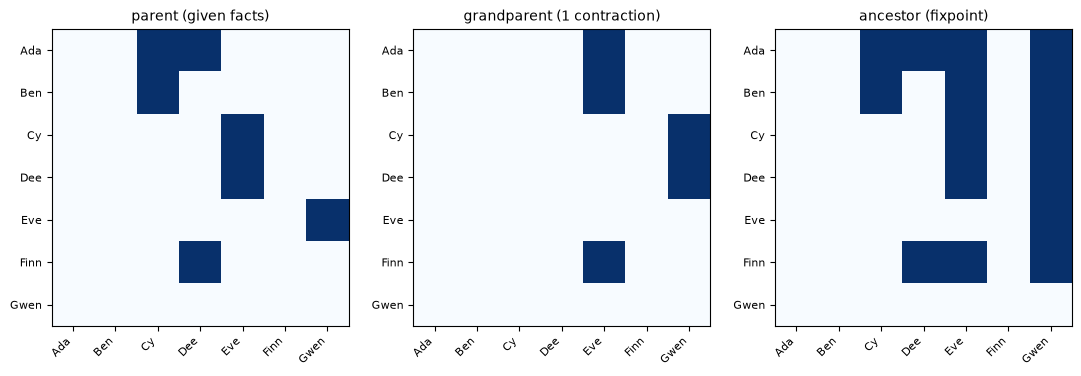

In [9]:
# [Result 02] The base facts and the two derived relations, side by side
fig, ax = plt.subplots(1, 3, figsize=(11, 3.6))
for a, M, t in zip(ax, [P, GP_tensor, A],
                   ["parent (given facts)", "grandparent (1 contraction)", "ancestor (fixpoint)"]):
    a.imshow(M, cmap="Blues", vmin=0, vmax=1)
    a.set_xticks(range(N)); a.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
    a.set_yticks(range(N)); a.set_yticklabels(names, fontsize=8)
    a.set_title(t, fontsize=10)
plt.tight_layout(); plt.show()

## What We Built, and What's Next

We computed real logical inference — `grandparent`, then recursive `ancestor` — with nothing but `einsum` contractions, proved it correct against hand-written logic loops bit-for-bit, and pinned down the one place the "logic = matmul" slogan is loose: the **semiring**. Over the reals the contraction counts derivation paths; logic needs the Boolean $\vee/\wedge$ semiring (or a clip) to recover truth values.

That semiring knob is the bridge to the next notebook. Swap Boolean truth for *probabilities* and the same contraction becomes **soft, differentiable** inference — at which point the quality of those probabilities (are they calibrated?) decides whether the reasoning is trustworthy. That is exactly the seam `01_confidence_gated_inference` puts under a microscope.